## A. Neural Network

### 3.1 MLP

> **做什么**：3层全连接网络做分类  

- ### 从零实现多层感知机

In [13]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# --- 激活函数 ---
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))  # 防溢出
    return e / e.sum(axis=1, keepdims=True)

# --- 从零实现MLP ---
class MLP:
    def __init__(self, layer_sizes, lr=0.01):
        """
        layer_sizes: 各层神经元数，如 [64, 128, 10] 表示输入64→隐藏128→输出10
        lr: 学习率
        """
        self.lr = lr
        self.n_layers = len(layer_sizes) - 1
        # Xavier初始化权重
        self.W = []
        self.b = []
        for i in range(self.n_layers):
            w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2.0 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))
            self.W.append(w)
            self.b.append(b)

    def forward(self, X):
        """前向传播：输入→隐藏层(ReLU)→输出层(Softmax)"""
        self.z = []   # 加权输入
        self.a = [X]  # 激活输出（第0层就是输入）
        for i in range(self.n_layers):
            z = self.a[-1] @ self.W[i] + self.b[i]
            self.z.append(z)
            if i < self.n_layers - 1:  # 隐藏层用ReLU
                a = relu(z)
            else:                       # 输出层用Softmax
                a = softmax(z)
            self.a.append(a)
        return self.a[-1]

    def backward(self, y_onehot):
        """反向传播：算梯度→更新参数"""
        m = y_onehot.shape[0]
        # 输出层梯度（softmax + 交叉熵 的简化公式）
        delta = self.a[-1] - y_onehot

        for i in range(self.n_layers - 1, -1, -1):
            dW = self.a[i].T @ delta / m
            db = delta.mean(axis=0, keepdims=True)
            if i > 0:  # 传到前一层的梯度
                delta = (delta @ self.W[i].T) * relu_deriv(self.z[i-1])
            # 梯度下降更新
            self.W[i] -= self.lr * dW
            self.b[i] -= self.lr * db

    def predict(self, X):
        prob = self.forward(X)
        return np.argmax(prob, axis=1)

# --- 加载数据 ---
digits = load_digits()
X = digits.data / 16.0  # 像素归一化到0~1
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# one-hot编码
n_classes = 10
y_train_oh = np.eye(n_classes)[y_train]

# --- 训练 ---
model = MLP(layer_sizes=[64, 128, 10], lr=0.1)  # 64输入→128隐藏→10输出

for epoch in range(200):
    prob = model.forward(X_train)
    model.backward(y_train_oh)
    if (epoch+1) % 50 == 0:
        loss = -np.log(prob[np.arange(len(y_train)), y_train] + 1e-8).mean()
        acc = (model.predict(X_train) == y_train).mean()
        print(f"Epoch {epoch+1:3d} | Loss: {loss:.4f} | 训练准确率: {acc:.4f}")

test_acc = (model.predict(X_test) == y_test).mean()
print(f"\n测试准确率: {test_acc:.4f}")

Epoch  50 | Loss: 0.8330 | 训练准确率: 0.8974
Epoch 100 | Loss: 0.4470 | 训练准确率: 0.9260
Epoch 150 | Loss: 0.3192 | 训练准确率: 0.9435
Epoch 200 | Loss: 0.2554 | 训练准确率: 0.9539

测试准确率: 0.9370


- ### 简洁实现多层感知机

In [14]:
import torch
import torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# --- 数据准备 ---
digits = load_digits()
X = digits.data / 16.0
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test)

# --- 定义网络（就这几行！） ---
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),   # 输入64 → 隐藏128
            nn.ReLU(),            # 激活函数
            nn.Linear(128, 10)    # 隐藏128 → 输出10
        )
    def forward(self, x):
        return self.net(x)

# --- 训练 ---
device = torch.device('cpu')
model = MLP().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    logits = model(X_train_t)
    loss = loss_fn(logits, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        pred = logits.argmax(dim=1)
        acc = (pred == y_train_t).float().mean()
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | 训练准确率: {acc:.4f}")

# --- 测试 ---
with torch.no_grad():
    pred = model(X_test_t).argmax(dim=1)
    acc = (pred == y_test_t).float().mean()
    print(f"\n测试准确率: {acc:.4f}")

Epoch  50 | Loss: 0.0346 | 训练准确率: 0.9952
Epoch 100 | Loss: 0.0081 | 训练准确率: 1.0000
Epoch 150 | Loss: 0.0036 | 训练准确率: 1.0000
Epoch 200 | Loss: 0.0020 | 训练准确率: 1.0000

测试准确率: 0.9796


- ### 经典案例：MNIST手写数字分类（28x28 -> 128 -> 64 -> 10）

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cpu')

# 加载MNIST数据集
transform = transforms.Compose([
    transforms.ToTensor(),                    # 转为[0,1]的Tensor
    transforms.Normalize((0.1307,), (0.3081,))  # 标准化
])
train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST('./data', train=False, transform=transform)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64)

# 定义3层MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)  # 输入层->隐藏层1
        self.fc2 = nn.Linear(128, 64)     # 隐藏层1->隐藏层2
        self.fc3 = nn.Linear(64, 10)      # 隐藏层2->输出层
    def forward(self, x):
        x = x.view(-1, 28*28)             # 展平为向量
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)                # CrossEntropyLoss内含softmax

model = MLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# 训练
for epoch in range(5):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        loss = criterion(model(X_batch), y_batch)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    # 测试
    model.eval()
    correct = sum((model(Xb.to(device)).argmax(1) == yb.to(device)).sum().item()
                  for Xb, yb in test_loader)
    print(f"Epoch {epoch+1}, Test Acc: {correct/len(test_set):.4f}")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 3598240.47it/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 112097.39it/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 1061124.62it/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<?, ?it/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Epoch 1, Test Acc: 0.9628
Epoch 2, Test Acc: 0.9685
Epoch 3, Test Acc: 0.9733
Epoch 4, Test Acc: 0.9733
Epoch 5, Test Acc: 0.9741


### 3.2 CNN（卷积神经网络）

> **做什么**：卷积提取局部特征+池化降维，适合图像分类  
> **经典案例**：FashionMNIST分类

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cpu')

# 加载FashionMNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST('./data', train=False, transform=transform)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64)

# 定义CNN
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)   # 28x28->28x28, 32通道
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)   # 14x14->14x14, 64通道
        self.pool = nn.MaxPool2d(2, 2)                  # 2x2最大池化
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))       # 28->14
        x = self.pool(torch.relu(self.conv2(x)))       # 14->7
        x = x.view(-1, 64*7*7)                          # 展平
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = criterion(model(Xb), yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    model.eval()
    acc = sum((model(Xb.to(device)).argmax(1)==yb.to(device)).sum().item()
              for Xb,yb in test_loader) / len(test_set)
    print(f"Epoch {epoch+1}, Acc: {acc:.4f}")

100%|██████████| 26421880/26421880 [00:03<00:00, 8317943.88it/s] 


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29515/29515 [00:00<00:00, 109678.59it/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4422102/4422102 [00:01<00:00, 3158665.59it/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5148/5148 [00:00<00:00, 318399.72it/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Epoch 1, Acc: 0.8789
Epoch 2, Acc: 0.9008
Epoch 3, Acc: 0.9062
Epoch 4, Acc: 0.9134
Epoch 5, Acc: 0.9125


- ### 现代卷积神经网络

>经典CNN（如LeNet）是深度学习在视觉领域的‘初步尝试’，现代CNN是在此基础上，针对深度退化问题和训练效率进行的全方位革新。其中，残差结构（ResNet） 和批量归一化（BN） 是区分‘经典’与‘现代’最显著的两个标志。

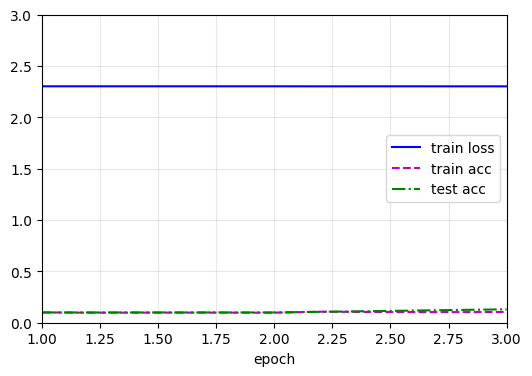

loss 2.302, train acc 0.105, test acc 0.131


In [9]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# ============================
# d2l 替换函数
# ============================

def load_data_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    train_set = torchvision.datasets.FashionMNIST(
        root='D:/datasets', train=True, transform=trans, download=True)
    test_set = torchvision.datasets.FashionMNIST(
        root='D:/datasets', train=False, transform=trans, download=True)
    return (torch.utils.data.DataLoader(train_set, batch_size, shuffle=True, num_workers=0),
            torch.utils.data.DataLoader(test_set, batch_size, shuffle=False, num_workers=0))


class Animator:
    def __init__(self, xlabel=None, ylabel=None, legend=None,
                 xlim=None, ylim=None):
        self.xlabel, self.ylabel = xlabel, ylabel   # ← 这行！
        self.legend = legend or []
        self.X = [[] for _ in self.legend]
        self.Y = [[] for _ in self.legend]
        self.xlim, self.ylim = xlim, ylim

    def add(self, x, ys):
        """x是横坐标，ys是各系列y值列表（None表示该系列本次不更新）"""
        for i, yi in enumerate(ys):
            if yi is not None:
                self.X[i].append(x)
                self.Y[i].append(yi)
        # 重绘
        styles = ['b-', 'm--', 'g-.', 'r:']
        plt.figure(figsize=(6, 4))
        for i in range(len(self.legend)):
            if len(self.X[i]) > 0:
                plt.plot(self.X[i], self.Y[i], styles[i % len(styles)],
                         label=self.legend[i])
        plt.xlabel(self.xlabel or '')
        plt.ylabel(self.ylabel or '')
        if self.xlim: plt.xlim(self.xlim)
        if self.ylim: plt.ylim(self.ylim)
        plt.legend()
        plt.grid(True, alpha=0.3)
        clear_output(wait=True)
        display(plt.gcf())
        plt.close()


def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],
                        legend=['train loss', 'train acc', 'test acc'],
                        ylim=[0, 3.0])
    num_batches = len(train_iter)
    for epoch in range(num_epochs):
        net.train()
        metric = [0.0, 0.0, 0]  # loss_sum, acc_sum, total
        for i, (X, y) in enumerate(train_iter):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = net(X)
            l = loss_fn(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric[0] += l.item() * y.numel()
                metric[1] += (y_hat.argmax(1) == y).sum().item()
                metric[2] += y.numel()
            # 每20%进度画一次
            if (i + 1) % max(num_batches // 5, 1) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2],
                              metric[1] / metric[2], None))
        # 测试
        net.eval()
        test_acc, test_total = 0, 0
        with torch.no_grad():
            for X, y in test_iter:
                X, y = X.to(device), y.to(device)
                test_acc += (net(X).argmax(1) == y).sum().item()
                test_total += y.numel()
        animator.add(epoch + 1,
                     (None, None, test_acc / test_total))
    print(f'loss {metric[0]/metric[2]:.3f}, '
          f'train acc {metric[1]/metric[2]:.3f}, '
          f'test acc {test_acc/test_total:.3f}')


# ============================
# VGG 网络
# ============================

def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels,
                                kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)


def vgg(conv_arch):
    conv_blks = []
    in_channels = 1
    out_channels_last = 0
    for (num_convs, out_channels) in conv_arch:
        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels
        out_channels_last = out_channels
    return nn.Sequential(
        *conv_blks,
        nn.AdaptiveAvgPool2d((7, 7)),
        nn.Flatten(),
        nn.Linear(out_channels_last * 7 * 7, 4096),
        nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(4096, 10)
    )


# 缩小版VGG（通道数÷4）
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))
ratio = 4
small_conv_arch = [(pair[0], pair[1] // ratio) for pair in conv_arch]
net = vgg(small_conv_arch)

# 加载数据
batch_size = 64
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=96)

# 超参数
lr, num_epochs = 0.05, 3   # 改成3个epoch，1个epoch曲线看不太出来
device = torch.device('cpu')

# 开始训练
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

### 3.3 RNN（循环神经网络）

> **做什么**：处理序列数据，每步维护隐藏状态  
> **经典案例**：字符级RNN姓名国籍分类


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import string

device = torch.device('cpu')
all_letters = string.ascii_letters + " .,;'"  # 可用字符集
n_letters = len(all_letters)
# 国籍列表
categories = ['Chinese','English','French','German','Italian',
              'Japanese','Korean','Polish','Portuguese','Russian',
              'Spanish','Vietnamese']
n_categories = len(categories)

# 字符->独热向量
def letter_to_tensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][all_letters.find(letter)] = 1
    return tensor

# 名字->字符张量序列
def name_to_tensor(name):
    return torch.cat([letter_to_tensor(c) for c in name])

# 字符级RNN
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size)       # RNN层
        self.fc = nn.Linear(hidden_size, output_size)     # 输出层
    def forward(self, x):
        out, hidden = self.rnn(x.unsqueeze(1))            # x: (seq_len, 1, input_size)
        return self.fc(hidden[-1].squeeze())               # 取最后隐藏状态分类

# 模拟训练演示（完整版需下载names数据）
model = CharRNN(n_letters, 128, n_categories).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

# 演示：用模拟数据训练
for i in range(100):
    name_t = name_to_tensor('Zhang')
    target = torch.tensor([0])  # Chinese=0
    output = model(name_t.to(device))
    loss = criterion(output.unsqueeze(0), target.to(device))
    optimizer.zero_grad(); loss.backward(); optimizer.step()

# 预测
with torch.no_grad():
    test_name = name_to_tensor('Satoshi').to(device)
    pred = model(test_name).argmax().item()
    print(f"'Satoshi' -> Predicted: {categories[pred]}")

'Satoshi' -> Predicted: Chinese
